In [35]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# Predicting Freight Cost

## Objective
Predict the **Freight Cost** for a vendor invoice using features like **Quantity** and **Dollar Amount**. This helps improve:

- Cost forecasting
- Budget planning
- Vendor negotiation

### Why is this important?

- Freight is a significant part of the total landed cost.
- Poor freight estimates can reduce profit margins and affect inventory planning.
- Automating freight cost estimation allows procurement teams to estimate the actual cost before the invoice arrives.

In [36]:
conn = sqlite3.connect(r"C:\Users\sanid\Downloads\invoice intelligence\data\inventory.db")

In [37]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [38]:
for table in tables['name']:
    print("Table Name:", table)

    df = pd.read_sql_query(
        f"SELECT * FROM {table} LIMIT 5",
        conn
    )

    display(df)

Table Name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table Name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table Name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table Name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table Name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [39]:
vendor_df = pd.read_sql_query(
    "SELECT * FROM vendor_invoice",
    conn
)

vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [40]:
vendor_df[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


## Relationship Between Quantity, Dollars, and Freight

Before training a Machine Learning model, it is useful to visualize how the features are related to the target variable.

Here, we will:

- Plot a **Correlation Heatmap** to measure the strength of relationships between variables.
- Plot **Scatter Plots** to observe how **Quantity** and **Dollars** affect the **Freight Cost**.

These visualizations help us understand whether a linear regression model is suitable for predicting freight cost.

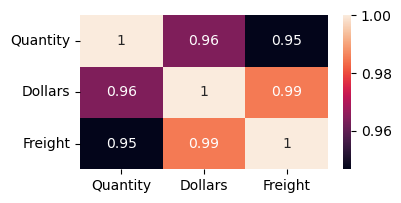

In [41]:
# Relationship between Quantity, Dollars, and Freight

plt.figure(figsize=(4, 2))

sns.heatmap(
    vendor_df[['Quantity', 'Dollars', 'Freight']].corr(),
    annot=True
)

plt.show()

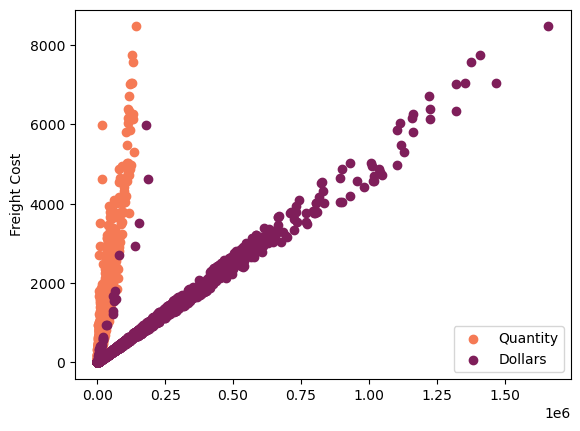

In [42]:
plt.scatter(
    vendor_df['Quantity'],
    vendor_df['Freight'],
    color='#f57a55'
)

plt.scatter(
    vendor_df['Dollars'],
    vendor_df['Freight'],
    color='#7f1e5a'
)

plt.legend(['Quantity', 'Dollars'])

plt.ylabel('Freight Cost')

plt.show()

## Feature Engineering - Freight Cost Per Unit

Instead of using only the total freight cost, we create a new feature called **Freight Per Unit**.

### Formula

\[
{Freight Per Unit} = (Freight)\/(Quantity)]

This feature helps us understand how much freight is paid for each unit of the product.

Next, we calculate the **25th percentile (Q1)** and **75th percentile (Q3)** of the `Quantity` column. These values help us divide the data into:

- **Low Quantity Orders** (below Q1)
- **Medium Quantity Orders** (between Q1 and Q3)
- **High Quantity Orders** (above Q3)

This analysis helps us determine whether ordering in larger quantities reduces the freight cost per unit.

In [43]:
# Create a new feature: Freight Cost Per Unit

vendor_df['freight_per_unit'] = (
    vendor_df['Freight'] / vendor_df['Quantity']
)

In [44]:
# Calculate the 25th and 75th percentile of Quantity

low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

print("High Quantity (Q3):", high_quantity)
print("Low Quantity (Q1):", low_quantity)

High Quantity (Q3): 5100.5
Low Quantity (Q1): 83.0


In [45]:
vendor_df.loc[
    vendor_df['Quantity'] < low_quantity,
    'freight_per_unit'
]

0       0.578333
1       0.571333
2       0.922000
5       0.100000
7       0.881667
          ...   
5523    0.102778
5526    0.088308
5527    0.048611
5528    0.032000
5537    0.053333
Name: freight_per_unit, Length: 1384, dtype: float64

In [46]:
vendor_df.loc[
    vendor_df['Quantity'] < high_quantity,
    'freight_per_unit'
]

0       0.578333
1       0.571333
2       0.922000
4       0.221809
5       0.100000
          ...   
5536    0.085419
5537    0.053333
5538    0.095556
5539    0.040394
5542    0.037986
Name: freight_per_unit, Length: 4157, dtype: float64

## Comparing Average Freight Cost Per Unit

Now, we compare the **average freight cost per unit** for:

- **Low Quantity Orders** (Quantity < Q1)
- **High Quantity Orders** (Quantity > Q3)

This helps us determine whether ordering in larger quantities reduces the shipping cost per unit.

In [47]:
vendor_df.loc[
    vendor_df['Quantity'] < low_quantity,
    'freight_per_unit'
].mean()

np.float64(0.09489854253138316)

In [48]:
vendor_df.loc[
    vendor_df['Quantity'] > high_quantity,
    'freight_per_unit'
].mean()

np.float64(0.049077654690759046)

# Machine Learning Model

After completing the Exploratory Data Analysis (EDA), we are ready to build a Machine Learning model.

Our objective is to predict the **Freight Cost** using the following input features:

- **Quantity**
- **Dollars**

The target variable is:

- **Freight**

We will:
1. Select the input and output variables.
2. Explore the numerical summary of the dataset.
3. Split the data into training and testing sets.
4. Train different regression models.
5. Compare their performance using evaluation metrics.

In [49]:
# Input Features
X = vendor_df[['Dollars']]

# Target Variable
y = vendor_df['Freight']

In [50]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Training and Evaluating Machine Learning Models

Now that the data has been prepared and split into training and testing sets, we will train multiple regression models.

The models used are:

- Linear Regression
- Decision Tree Regression
- Random Forest Regression

After training, each model will be evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Finally, we will compare the performance of all models to determine which one predicts freight cost most accurately.

In [53]:
# Linear Regression
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Decision Tree Regression
model2 = DecisionTreeRegressor(max_depth = 4, random_state=42)
model2.fit(X_train, y_train)

# Random Forest Regression
model3 = RandomForestRegressor(max_depth = 6, random_state=42)
model3.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, random_state=42)

## Model Evaluation

After training the models, we evaluate how accurately they predict freight cost on the testing dataset.

The evaluation metrics are:

- **MAE (Mean Absolute Error)** → Average prediction error.
- **RMSE (Root Mean Squared Error)** → Gives higher penalty to larger errors.
- **R² Score** → Indicates how well the model explains the variation in freight cost.

A good regression model should have:

- Low MAE
- Low RMSE
- High R² Score

In [54]:
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")

In [55]:
# Evaluate Linear Regression
evaluate_model(model1, X_test, y_test, "Linear Regression")

# Evaluate Decision Tree Regression
evaluate_model(model2, X_test, y_test, "Decision Tree Regression")

# Evaluate Random Forest Regression
evaluate_model(model3, X_test, y_test, "Random Forest Regression")


Linear Regression Performance:
MAE  : 24.11
RMSE : 124.72
R²   : 96.99%

Decision Tree Regression Performance:
MAE  : 38.12
RMSE : 138.25
R²   : 96.30%

Random Forest Regression Performance:
MAE  : 26.13
RMSE : 134.79
R²   : 96.48%


## Linear Regression Visualization

To better understand the performance of the Linear Regression model, we plot:

- Actual data points (Dollars vs Freight)
- Predicted regression line

The scatter plot shows the actual observations, while the red line represents the predictions made by the Linear Regression model.

If the points are close to the regression line, it indicates that the model fits the data well.

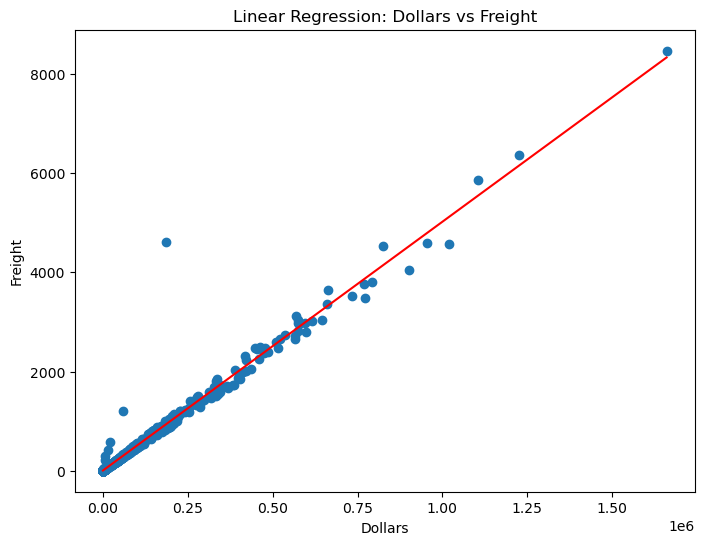

In [56]:
X_sorted = X_test.sort_values(by="Dollars")
y_pred = model1.predict(X_sorted)

plt.figure(figsize=(8, 6))

plt.scatter(X_test, y_test)
plt.plot(X_sorted, y_pred, color="red")

plt.xlabel("Dollars")
plt.ylabel("Freight")
plt.title("Linear Regression: Dollars vs Freight")

plt.show()

# Inference (Making Predictions)

After training and evaluating the model, we can use it to predict the freight cost for new invoices.

This process is called **Inference**.

The model takes the input feature(s) and returns the predicted freight cost.

Since our model was trained using only the **Dollars** feature, the input for prediction must also contain only the **Dollars** column.

In [57]:
# New invoice data

input_data = {
    "Dollars": [18500, 9000]
}

df = pd.DataFrame(input_data)

In [58]:
model1.predict(df)

array([97.78868161, 50.14455838])